#### Loading packages

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Setting root directory path

In [146]:
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\data-analytics-python'


#### Data source used: NLSY97

The NLSY97 is a `longitudinal` (i.e. `panel`) survey of individuals born between 1980 and 1984. The first round of data collection took place in 1997 and was followed by additional survey rounds every one or two years.


#### Loading data

Reminder: We need the `pyarrow` package to import a `.parquet` datafile.

In [147]:
nlsy97_income_hours_all_df = pd.read_parquet(ROOT + '/data/nlsy97_income_hours_all_df.parquet')
nlsy97_additional_vars_df = pd.read_parquet(ROOT + '/data/nlsy97_additional_vars_df.parquet')


#### Dictionary of variable labels

In [148]:
long_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Completed (Biological Mother)',
    'meduc_res': 'Highest Grade Completed (Residential Mother)',
    'feduc_bio': 'Highest Grade Completed (Biological Father)',
    'feduc_res': 'Highest Grade Completed (Residential Father)',
    'educ_num': 'Inferred Years of Education',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Education (Biological Mother)',
    'meduc_res_num': 'Inferred Years of Education (Residential Mother)',
    'feduc_bio_num': 'Inferred Years of Education (Biological Father)',
    'feduc_res_num': 'Inferred Years of Education (Residential Father)',
    'meduc_bio_cat': 'Inferred Degree (Biological Mother)',
    'meduc_res_cat': 'Inferred Degree (Residential Mother)',
    'feduc_bio_cat': 'Inferred Degree (Biological Father)',
    'feduc_res_cat': 'Inferred Degree (Residential Father)',
    'hh_yinc_1997': 'Household Income in 1997',
    'hh_yinc_source_1997': 'Source of Household Income in 1997', 
    'hh_net_worth_1997': 'Household Net Worth in 1997'
}


short_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Compl. (Biol. Mother)',
    'meduc_res': 'Highest Grade Compl. (Resid. Mother)',
    'feduc_bio': 'Highest Grade Compl. (Biol. Father)',
    'feduc_res': 'Highest Grade Compl. (Resid. Father)',
    'educ_num': 'Inferred Years of Educ.',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Educ. (Biol. Mother)',
    'meduc_res_num': 'Inferred Years of Educ. (Resid. Mother)',
    'feduc_bio_num': 'Inferred Years of Educ. (Biol. Father)',
    'feduc_res_num': 'Inferred Years of Educ. (Resid. Father)',
    'meduc_bio_cat': 'Inferred Highest Degree (Biol. Mother)',
    'meduc_res_cat': 'Inferred Highest Degree (Resid. Mother)',
    'feduc_bio_cat': 'Inferred Highest Degree (Biol. Father)',
    'feduc_res_cat': 'Inferred Highest Degree (Resid. Father)',
    'hh_yinc_1997': 'HH Income in 1997',
    'hh_yinc_source_1997': 'Source of HH Income in 1997', 
    'hh_net_worth_1997': 'HH Net Worth in 1997'
}

#### Intergenerational Transmission of Educational Attainment (mother/father)

In the NLSY97 there are two commonly used measures of educational attainment:

 - highest grade completed (here the variable `educ`)
 - highest degree earned (here the variable `degree`)

The variable `educ` records the highest grade or year of education completed, while `degree` records the highest educational credential earned (e.g. high school diploma, bachelor's degree, master's degree).

For the parents of respondents, only a measure corresponding to highest grade completed is available. The relevant variables are:

 - highest grade completed by the biological mother (`meduc_bio`)
 - highest grade completed by the residential mother (`meduc_res`)
 - highest grade completed by the biological father (`feduc_bio`)
 - highest grade completed by the residential father (`feduc_res`)


Let us first look at the content of the `educ`-type variables. These are ordered categorical variables.

In [149]:
nlsy97_additional_vars_df['educ'].dtype

CategoricalDtype(categories=['1st grade', '2nd grade', '3rd grade', '4th grade',
                  '5th grade', '6th grade', '7th grade', '8th grade',
                  '9th grade', '10th grade', '11th grade', '12th grade',
                  '1st year college', '2nd year college', '3rd year college',
                  '4th year college', '5th year college', '6th year college',
                  '7th year college', '8th year college or more'],
, ordered=True, categories_dtype=str)

Let us plot the histogram of highest grade completed for participants, their mothers, their fathers for the representative sub-sample (`sample='Cross-sectional'`).

In [150]:
nlsy97_additional_vars_df['sample'].value_counts()

sample
Cross-sectional    6748
Oversample         2236
Name: count, dtype: int64[pyarrow]

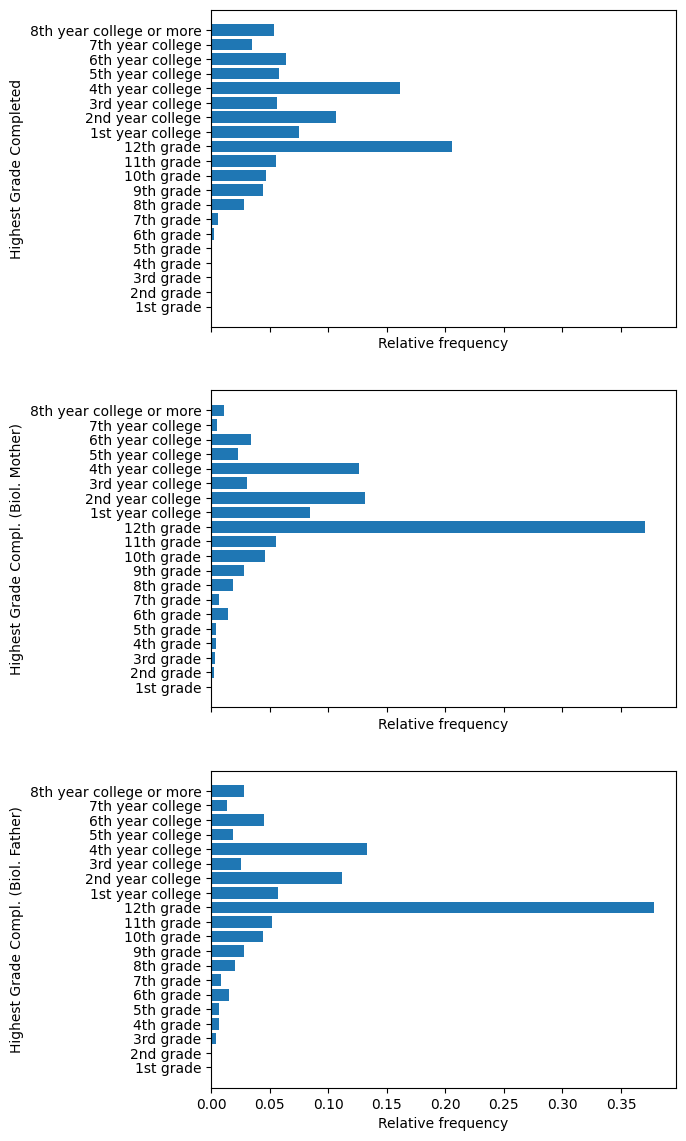

In [151]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,14), sharex=True, sharey=True)
varnames = ['educ', 'meduc_bio', 'feduc_bio']

for i, varname in enumerate(varnames):
    df = nlsy97_additional_vars_df.copy()
    df = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .reset_index()
            .sort_values(varname)
            .reset_index(drop=True)
    )
    axs[i].barh(y=df[varname].astype(str), width=df['proportion'], height=0.8)
    axs[i].set_xlabel('Relative frequency')
    axs[i].set_ylabel(short_varlabels_dict[varname])

There are corresponding variables (`educ_num`, `meduc_bio_num`, `meduc_res_num`, `feduc_bio_num`, `feduc_res_num`) that translate these ordered categorical variables into a numerical variable (years of education).



In [152]:
varname = 'educ'
df = nlsy97_additional_vars_df.copy()
df = (
    df[[varname, varname + '_num']]
        .loc[df['sample'].eq('Cross-sectional'),:]
        .value_counts(normalize=True)
        .reset_index()
        .sort_values([varname, varname + '_num'])
        .reset_index(drop=True)
        .copy()
)
df = df.loc[df['proportion'].ne(0),:].copy()
df

,educ,educ_num,proportion
17,2nd grade,2,0.000150
69,5th grade,5,0.000750
87,6th grade,6,0.002850
105,7th grade,7,0.005551
123,8th grade,8,0.028503
141,9th grade,9,0.044704
159,10th grade,10,0.046805
177,11th grade,11,0.055206
195,12th grade,12,0.205371
213,1st year college,13,0.074857


The `degree` variable exists only for the study participants, but not for their parents. It is an ordered categorical variable.

In [153]:
df = nlsy97_additional_vars_df.copy()
df['degree'].dtype


CategoricalDtype(categories=['No degree', 'GED', 'High school', 'Junior college',
                  'Bachelor', 'Master', 'Professional', 'PhD'],
, ordered=True, categories_dtype=str)

In [154]:
df0 = df.loc[
    df['educ'].notna() & df['degree'].isna(),
    ['educ', 'degree']
].value_counts(dropna=False).reset_index().copy()

df0 = df0.loc[df0['count'] > 0,:]

df0.sort_values('educ')

,educ,degree,count
0,12th grade,NaN,19
1,1st year college,NaN,6
2,2nd year college,NaN,2
3,3rd year college,NaN,2
7,4th year college,NaN,1
5,5th year college,NaN,1
6,6th year college,NaN,1
4,7th year college,NaN,1


Let us recode participants' and parents' highest grade completed into broader categories.

For participants, we use the following rule:

$$
educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } degree = \text{No degree} \text{ or } degree = \text{GED}\\
\text{High School} & \text{if } degree = \text{High school} \text{ and } educ\_num \leq 12\\
\text{Some College} & \text{if } (degree = \text{High school} \text{ and } educ\_num > 12) \text{ or } degree = \text{Junior college}\\
\text{Bachelor Plus} & \text{if } degree \in \{\text{Bachelor}, \text{Master}, \text{Professional}, \text{PhD}\}
\end{cases}
$$

For parents, we use the following rule:

$$
[m/f]educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } [m/f]educ\_num \leq 11\\
\text{High School} & \text{if } [m/f]educ\_num = 12\\
\text{Some College} & \text{if } [m/f]educ\_num \in [13,15] \\
\text{Bachelor Plus} & \text{if } [m/f]educ\_num \geq 16
\end{cases}
$$



In [155]:
df = nlsy97_additional_vars_df.copy()
varnames = ['meduc_bio', 'meduc_res', 'feduc_bio', 'feduc_res']
categories = ['Less than High School', 'High School', 'Some College', 'Bachelor Plus']
for varname in varnames:
    df[varname + '_cat'] = pd.NA 
    df.loc[df[varname + '_num'].lt(12), varname + '_cat'] = categories[0]
    df.loc[df[varname + '_num'].eq(12), varname + '_cat'] = categories[1]
    df.loc[df[varname + '_num'].gt(12) & df[varname + '_num'].lt(16), varname + '_cat'] = categories[2]
    df.loc[df[varname + '_num'].ge(16), varname + '_cat'] = categories[3]
    df[varname + '_cat'] = pd.Categorical(df[varname + '_cat'], categories=categories, ordered=True)


df['educ_cat'] = pd.NA
df.loc[df['degree'].eq('No degree'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('GED'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('High school') & df['educ_num'].le(12), 'educ_cat'] = categories[1]
df.loc[df['degree'].eq('High school') & df['educ_num'].gt(12), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Junior college'), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Bachelor'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Master'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Professional'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('PhD'), 'educ_cat'] = categories[3]
df['educ_cat'] = pd.Categorical(df['educ_cat'], categories=categories, ordered=True)

nlsy97_additional_vars_df = df.copy()        

In [156]:
nlsy97_additional_vars_df['educ_cat'].dtype

CategoricalDtype(categories=['Less than High School', 'High School', 'Some College',
                  'Bachelor Plus'],
, ordered=True, categories_dtype=str)

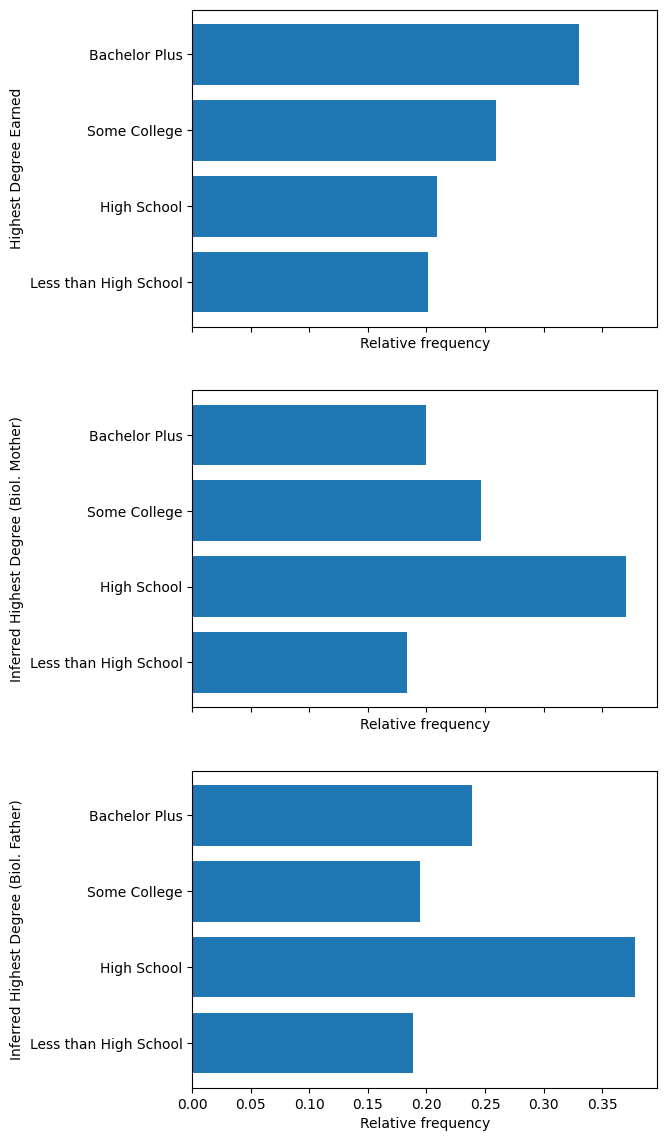

In [157]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,14), sharex=True, sharey=True)
varnames = ['educ_cat', 'meduc_bio_cat', 'feduc_bio_cat']

for i, varname in enumerate(varnames):
    df = nlsy97_additional_vars_df.copy()
    df = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .reset_index()
            .sort_values(varname)
            .reset_index(drop=True)
    )
    axs[i].barh(y=df[varname].astype(str), width=df['proportion'], height=0.8)
    axs[i].set_xlabel('Relative frequency')
    axs[i].set_ylabel(short_varlabels_dict[varname])

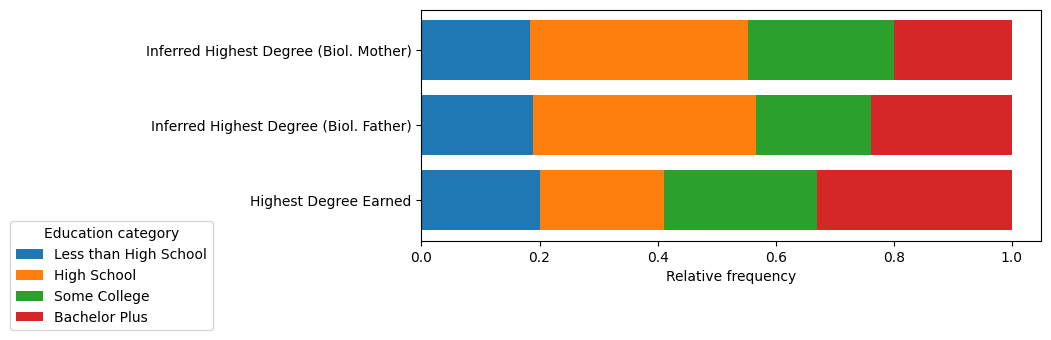

In [158]:
df = nlsy97_additional_vars_df.copy()
varnames = ['educ_cat', 'meduc_bio_cat', 'feduc_bio_cat']
plot_df = pd.DataFrame()
for varname in varnames:

    tmp = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .rename('proportion')
            .reset_index()
            .copy()
    )

    tmp['varname'] = varname 
    tmp['varlabel'] = short_varlabels_dict[varname]
    tmp['category'] = tmp[varname]
    tmp = tmp.drop(columns=varname)

    plot_df = pd.concat([plot_df, tmp], ignore_index=True)

plot_df = plot_df.sort_values(by=['varname', 'category']).reset_index(drop=True).copy()
plot_df['cumulative_proportion_below'] = plot_df.groupby('varname')['proportion'].cumsum() - plot_df['proportion']

categories = plot_df['category'].sort_values().drop_duplicates().to_list()

fig, ax = plt.subplots(figsize=(8, 3))

for category in categories:

    plot_df_cat = plot_df.loc[plot_df['category'].eq(category), :].sort_values(by=['varname']).copy()
    ax.barh(
        y=plot_df_cat['varlabel'],
        width=plot_df_cat['proportion'],
        left=plot_df_cat['cumulative_proportion_below'],
        label=category
    )

ax.set_xlabel('Relative frequency')
ax.legend(title='Education category', loc='center', bbox_to_anchor=(-0.5, -0.15))

Our main objective is intergenerational transmission of educational attainment.

##### Distribution of highest degree earned by parents' inferred highest degree earned.

Our target object of interest could be the probability distribution of highest degree earned conditional on each parent's inferred highest degree.

$$
\mathbb{P}[educ\_cat \ |\ \ meduc\_cat ]
$$

$$
\mathbb{P}[educ\_cat \ |\ \ feduc\_cat ]
$$

These are conditional probabilities. In our observed data, we can compute the corresponding conditional relative frequencies.


$$
\mathbb{P}[Y|X]
$$
where $Y$ is the `outcome variable` and $X$ is the `conditioning variable`


Statistical independence:
$$
\mathbb{P}[Y|X] =  \mathbb{P}[Y]
$$
strong measure of unrelatedness between variables

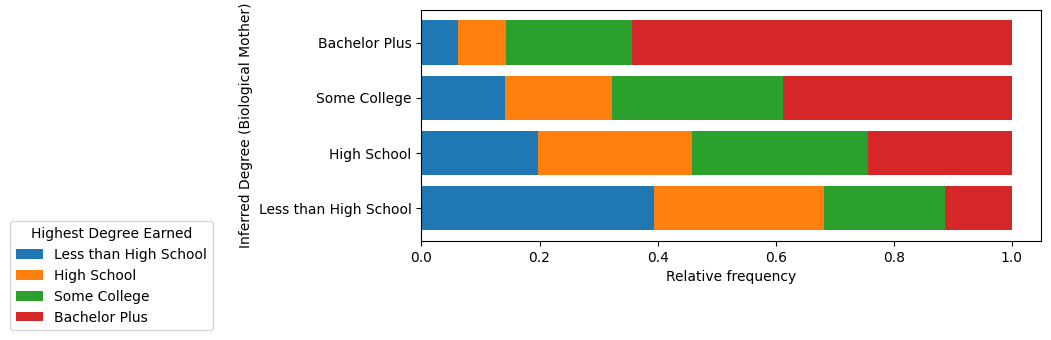

In [160]:
df = nlsy97_additional_vars_df.copy()
# conditioning variable parent educational attainment
conditioning_var = 'meduc_bio_cat'
# outcome variable child educational attainment
outcome_var = 'educ_cat'

df_subset = df.loc[df['sample'].eq('Cross-sectional'), [outcome_var, conditioning_var]].copy()

# conditional relative frequencies
plot_df = df_subset.groupby(conditioning_var).value_counts(subset=[outcome_var], normalize=True).reset_index().sort_values(by=[conditioning_var, outcome_var]).reset_index(drop=True).copy()

# cumulative proportions below -> where each bar segment begins 
plot_df['cumulative_proportion_below'] = (
    plot_df
        # within each value of parent education
        .groupby(conditioning_var)['proportion']
        # for each value V of child education
        # share of observations with level L < V 
        .cumsum() - plot_df['proportion']

)
# collecting categories / levels (distinct values) for the outcomes variable 
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().to_list()

fig, ax = plt.subplots(figsize=(8, 3))

# iterating over the values of child education
for outcome_var_cat in outcome_var_categories:
   
    # restriction by outcome variable value
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat), :].sort_values(by=[conditioning_var]).copy()
    
    ax.barh(
        # vertical axis: conditioning variable / parent education
        y=plot_df_cat[conditioning_var],
        # horizontal axis: stacked proportions of observations associated with distinct values of the outcome variable
        width=plot_df_cat['proportion'],
        left=plot_df_cat['cumulative_proportion_below'],
        label=outcome_var_cat
    )

ax.set_xlabel('Relative frequency')
ax.set_ylabel(long_varlabels_dict[conditioning_var])
# colour coding
ax.legend(title=short_varlabels_dict[outcome_var], loc='center', bbox_to_anchor=(-0.5, -0.15))




#### Intergenerational Income Mobility

Let us now investigate distribution of participants' 2023 income quintile (in the last observed year when participants are about 40 years old) conditional on the income quintile of their household income in 1997 (when participants are between 13 and 17 years old).


Adding income data from 2023 to the dataframe with the other variables:

In [161]:
# dataframe with income and hours
incomes_df = nlsy97_income_hours_all_df.copy()

incomes_df = (
    incomes_df
        # select rows (year = 2023) and columns (id, income, hours)
        .loc[incomes_df['year'].eq(2023), ['person_id', 'yinc', 'yhours']]
        # rename the income and hours variables
        .rename(columns={'yinc': 'yinc_2023', 'yhours': 'yhours_2023'})
        .copy()
)

# merging with the dataframe containing the other variables
incomes_df = pd.merge(left=nlsy97_additional_vars_df, # df with other variables
                      right=incomes_df, # df just created
                      on='person_id', # person id (uniqeness should normally be checked)
                      how='left') # left-join (keep all observations from left, add only matching observations from right)



Group observations by income rank into five equal groups (in ascending order)
 - by income rank in 1997 (parental income rank around the age of 15)
 - by income rank in 2023 (child income rank around the age of 40)



For both income variables, let us create five income quantile groups based on the income quantiles:
 - first quintile: $[Q(0), Q(0.2)]$ (between the 0% and the 20% point-quantile)
 - second quintile: $(Q(0.2), Q(0.4)]$ (between the 20% and the 40% point-quantile)
 - third quintile: $(Q(0.4), Q(0.6)]$ (between the 40% and the 60% point-quantile)
 - fourth quintile: $(Q(0.6), Q(0.8)]$ (between the 60% and the 80% point-quantile)
 - fifth quintile: $(Q(0.8), Q(1)]$ (between the 80% and the 100% point-quantile)


In [162]:
# We have variables hh_yinc_1997 (household income), yinc_2023 (labor income)
# Income concept is a little different
# Objective: hh_yinc_1997_Q (parent income quintile),  yinc_2023_Q (income quintile in 2023) 
 
df = incomes_df.copy()

dfs = {}

dfs['hh_yinc_1997'] = df.loc[df['hh_yinc_source_1997'].eq('Parent') & df['hh_yinc_1997'].notna() & df['sample'].eq('Cross-sectional'), ['person_id', 'hh_yinc_1997']].copy()
dfs['yinc_2023'] = df.loc[df['yinc_2023'].notna() & df['sample'].eq('Cross-sectional'), ['person_id', 'yinc_2023']].copy()
quintile_labels = ['1st Quintile', '2nd Quintile', '3rd Quintile', '4th Quintile', '5th Quintile']

for varname in ['hh_yinc_1997', 'yinc_2023']:

    df = dfs[varname].copy()
    
    # defining the 0%, 20%, 40%, 60%, 80%, 100% quantiles
    # to cut the distribution of income into five quintiles (equally sized intervals here)
    q0 = df[varname].min()
    q20 = df[varname].quantile(0.2)
    q40 = df[varname].quantile(0.4)
    q60 = df[varname].quantile(0.6)
    q80 = df[varname].quantile(0.8)
    q100 = df[varname].max()

    # defining the quintiles -> grouping observations into intervals
    incomes_df[varname + '_Q'] = pd.NA

    incomes_df.loc[incomes_df[varname].le(q20), varname + '_Q'] = quintile_labels[0]
    incomes_df.loc[incomes_df[varname].gt(q20) & incomes_df[varname].le(q40), varname + '_Q'] = quintile_labels[1]
    incomes_df.loc[incomes_df[varname].gt(q40) & incomes_df[varname].le(q60), varname + '_Q'] = quintile_labels[2]
    incomes_df.loc[incomes_df[varname].gt(q60) & incomes_df[varname].le(q80), varname + '_Q'] = quintile_labels[3]
    incomes_df.loc[incomes_df[varname].gt(q80), varname + '_Q'] = quintile_labels[4]

    incomes_df[varname + '_Q'] = pd.Categorical(incomes_df[varname + '_Q'], categories=quintile_labels, ordered=True)



Plotting.

Text(0, 0.5, 'Household Income Quintile in 1997')

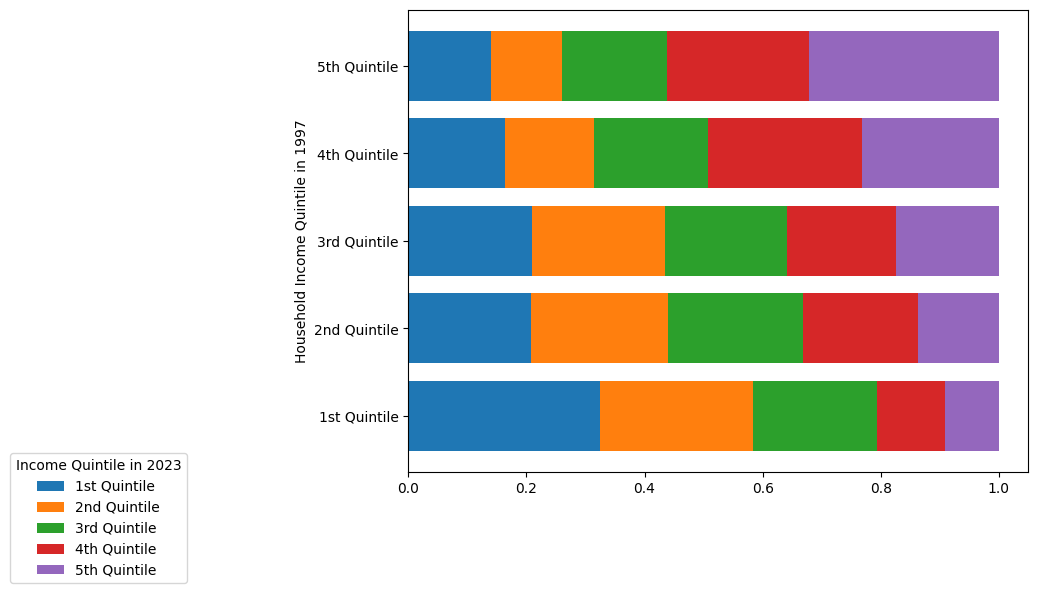

In [163]:
plot_df = incomes_df.copy()

plot_df = (
    plot_df
        # representative sub-sample
        .loc[plot_df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             plot_df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             plot_df['hh_yinc_1997'].notna() & 
             plot_df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']].copy()
)

conditioning_var = 'hh_yinc_1997_Q'
outcome_var = 'yinc_2023_Q'

# conditional relative frequencies
plot_df = (
    plot_df
        # within each of the conditioning variable (parent income quintile)
        .groupby(conditioning_var)
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=[outcome_var], normalize=True)
        .reset_index()
        .sort_values(by=[conditioning_var, outcome_var])
        .reset_index(drop=True)


)

# computing conditional cumulative proportions
# within each parent quintile
# for each child quintile
plot_df['cumulative_proportion_below'] = (
    plot_df
        .groupby(conditioning_var)['proportion']
        .cumsum() 
        - plot_df['proportion']
)

# collecting distinct values of the outcome variable
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().copy().to_list()

fig, ax = plt.subplots(figsize = (8,6))

for outcome_var_cat in outcome_var_categories:
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat),:].sort_values(conditioning_var).reset_index(drop=True)

    ax.barh(y=plot_df_cat[conditioning_var],
            left=plot_df_cat['cumulative_proportion_below'],
            width=plot_df_cat['proportion'],
            label=outcome_var_cat)

ax.legend(title='Income Quintile in 2023', loc ='center', bbox_to_anchor = (-0.5,-0.1))
ax.set_ylabel('Household Income Quintile in 1997')



If child income-quintile was `statistically independent` from parent income-quintile, then we should see:
$$
\mathbb{P}[\text{child income quintile} | \text{parent income quintile}] = 20\%
$$

#### Conditional distribution under independence

Let us artificially reassign child income quintile to see how the distribution could look like if child income quintile was independent from parent income quintile:

Text(0, 0.5, 'Household Income Quintile in 1997')

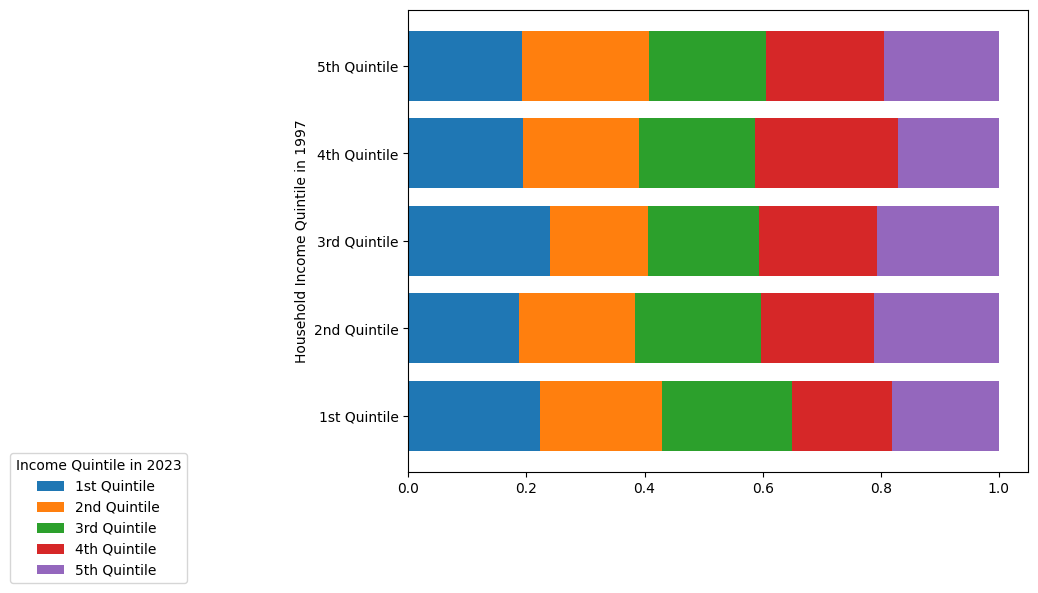

In [164]:
# Simulation -> complete independence

rng = np.random.default_rng(798312)

plot_df = incomes_df.copy()

plot_df = (
    plot_df
        # representative sub-sample
        .loc[plot_df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             plot_df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             plot_df['hh_yinc_1997'].notna() & 
             plot_df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']].copy()
)

# CREATING ARTIFICIAL DATA
# randomly reassign the income quintile around age 40
plot_df['yinc_2023_Q'] = rng.permutation(plot_df['yinc_2023_Q'])

conditioning_var = 'hh_yinc_1997_Q'
outcome_var = 'yinc_2023_Q'

# conditional relative frequencies
plot_df = (
    plot_df
        # within each of the conditioning variable (parent income quintile)
        .groupby(conditioning_var)
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=[outcome_var], normalize=True)
        .reset_index()
        .sort_values(by=[conditioning_var, outcome_var])
        .reset_index(drop=True)


)

# computing conditional cumulative proportions
# within each parent quintile
# for each child quintile
plot_df['cumulative_proportion_below'] = (
    plot_df
        .groupby(conditioning_var)['proportion']
        .cumsum() 
        - plot_df['proportion']
)

# collecting distinct values of the outcome variable
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().copy().to_list()

fig, ax = plt.subplots(figsize = (8,6))

for outcome_var_cat in outcome_var_categories:
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat),:].sort_values(conditioning_var).reset_index(drop=True)

    ax.barh(y=plot_df_cat[conditioning_var],
            left=plot_df_cat['cumulative_proportion_below'],
            width=plot_df_cat['proportion'],
            label=outcome_var_cat)

ax.legend(title='Income Quintile in 2023', loc ='center', bbox_to_anchor = (-0.5,-0.1))
ax.set_ylabel('Household Income Quintile in 1997')



#### Test(s) of Independence between Parent Income Quintile and Child Income Quintile

In [ ]:
df = incomes_df.copy()

df = (
    df
        # representative sub-sample
        .loc[df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             df['hh_yinc_1997'].notna() & 
             df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']]
             .rename(columns={'hh_yinc_1997_Q': 'parent',
                              'yinc_2023_Q': 'child'})
             .copy()
)

observed_df = df.copy()

For the actually observed sample, we have the following actual empirical conditional distribution:

In [ ]:
df = observed_df.copy()

df = (
    df
        # within each of the conditioning variable (parent income quintile)
        .groupby('parent')
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(by=['parent', 'child'])
        .reset_index(drop=True)
        .copy()
)

# reshaping 
observed_distr_df = df.pivot(columns='child', index='parent', values='proportion').copy()
observed_distr_df

After randomly permuting the child income quintiles, we obtain the following simulated empirical conditional distribution:

In [ ]:
rng = np.random.default_rng(798312)

df = observed_df.copy()
# randomly reassign the child income quintile 
df['child'] = rng.permutation(df['child'])

df = (
    df
        # within each of the conditioning variable (parent income quintile)
        .groupby('parent')
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(by=['parent', 'child'])
        .reset_index(drop=True)
        .copy()
)

one_permutation_df = df.copy()
one_permutation_distr_df = df.pivot(columns='child', index='parent', values='proportion').copy()


Under independence, the conditional distribution of child income quintiles should be identical across all parent income quintiles and equal to the unconditional (marginal) distribution:

$$
\mathbb{P}[\text{child quintile} \mid \text{parent quintile}]
=
\mathbb{P}[\text{child quintile}]
\qquad
\text{for all parent quintiles}
$$

The sample counterparts of the marginal probabilities $\mathbb{P}[\text{child quintile}]$ are the marginal relative frequencies observed in the data:

In [ ]:
df = (
    observed_df.value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(by=['child'])
        .reset_index(drop=True)
        .copy()
)


df = df.set_index('child').T.reset_index(drop=True).copy()
df = df.loc[df.index.repeat(5)].reset_index(drop=True).copy()
df.index = observed_distr_df.index.copy()
observed_unconditional_distr_df = df.copy()


Under the hypothesis of independence, the conditional distribution of child income quintiles should be similar across all parent income quintiles and should coincide with the unconditional (marginal) distribution of child income quintiles.

In the observed sample, the conditional distributions differ substantially across parent income quintiles.

However, even if parent and child income quintiles were truly independent in the population, random sampling variation could still generate conditional distributions that appear suggestive of statistical dependence.

Can we reject the hypothesis of independence? Is the observed conditional distribution so unusual that it would be unlikely to arise under independence?

To answer these questions more systematically, we need a measure of how far the observed conditional distribution deviates from what we would expect under independence.

Equivalently, we need a measure of how extreme the observed sample is relative to samples that could arise under the hypothesis of independence.

To quantify this extremeness, we choose a summary statistic that measures the degree of dependence.

One possibility is the Chi-Square Statistic, a summary measure of the discrepancy between observed joint frequencies and the joint frequencies implied by independence:

$$
T =
\sum_{\substack{i \in \text{Child Quintiles}\\ j \in \text{Parent Quintiles}}} \frac{(N_{i,j}(\text{observed}) - N_{i,j}(\text{expected under independence}))^2}{N_{i,j}(\text{expected under independence}) }
$$

where

- $N_{i,j}(\text{observed})$ is the observed frequency of observations with child income quintile $i$ and parent income quintile $j$;
- $N_{i,j}(\text{expected under independence})$ is the implied frequency of child income quintile $i$ among observations with parent income quintile $j$ under the hypothesis of independence.

Applying the definition of independence ($p_{i|j}(\text{expected under independence}) = p_{i}(\text{observed})$):

$$
N_{i,j}(\text{expected under independence}) = N_{j}(\text{observed}) \cdot p_{i|j}(\text{expected under independence}) = N_{j}(\text{observed}) \cdot p_{i}(\text{observed})
$$

where:
 - $N_{j}(\text{observed})$ is the observed frequency of parent income quintile $j$;
 - $p_{i|j}(\text{expected under independence})$ is the implied relative frequency of child income quintile $i$ among observations with parent income quintile $j$ under the hypothesis of independence;
 - $p_{i}(\text{observed})$ is the observed unconditional (or marginal) relative frequency of child income quintile $i$.

As a result, the Chi-Square Statistic becomes:

$$
T =
\sum_{\substack{i \in \text{Child Quintiles}\\ j \in \text{Parent Quintiles}}} \frac{(N_{i,j}(\text{observed}) - N_{j}(\text{observed}) \cdot p_{i}(\text{observed}))^2}{N_{j}(\text{observed}) \cdot p_{i}(\text{observed}) }
$$


In inferential statistics:

- the hypothesis of independence (in this example) is called the `null hypothesis`;
- the `summary measure` used to quantify `deviations from the null hypothesis` is called the `test statistic`;
- the `distribution of the test statistic` under the null hypothesis is called the `null distribution`.

There are two common approaches to approximate the null distribution:

- Simulation: Permutation Test
  - Approximate the distribution of the Chi-Square Statistic under independence through $R = 1000$ random permutations of child income quintiles.
  - For each permutation, recompute the Chi-Square Statistic.
  - The resulting empirical distribution approximates the null distribution.

- Large Sample Theory: Chi-Square Test
  - According to large-sample theory, the Chi-Square Statistic approximately follows a Chi-Square distribution under the null hypothesis of independence.
  - For a contingency table with $r$ rows and $c$ columns, the degrees of freedom are
$$
(r-1)(c-1).
$$
  - In our application, there are five parent income quintiles and five child income quintiles, implying $$(5-1)(5-1)=16$$ degrees of freedom such that under the null hypothesis of independence the Chi-Square Statistic approximately follows a Chi-Square Distribution with $16$ degrees of freedom:
$$
T \mid H_0 \overset{\text{\tiny approx.}}{\sim} \chi_{16}^2
$$


Let us first compute the observed value of the Chi-Square Statistic in the actual sample.

To do so, we need

- the observed joint frequencies $N_{i,j}$;
- the observed frequencies of parent income quintiles $N_j$;
- the observed marginal relative frequencies of child income quintiles $p_i$.

In [ ]:
df = observed_df.copy()
joint_frequencies_df = (
    df
        .value_counts(subset=['parent', 'child'])
        .reset_index()
        .sort_values(['parent', 'child'])
        .reset_index(drop=True)
        .rename(columns={'count': 'joint_frequency'})
        .copy()
)
joint_frequencies_df

parent_frequencies_df = (
    df
        .value_counts(subset=['parent'])
        .reset_index()
        .sort_values(['parent'])
        .reset_index(drop=True)
        .rename(columns={'count': 'parent_frequency'})
        .copy()
)
parent_frequencies_df


child_relative_frequencies_df = (
    df
        .value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(['child'])
        .reset_index(drop=True)
        .rename(columns={'proportion': 'child_relative_frequency'})
        .copy()
)
child_relative_frequencies_df

df = pd.merge(left=joint_frequencies_df, right=parent_frequencies_df, on='parent', how='left')
df = pd.merge(left=df, right=child_relative_frequencies_df, on='child', how='left')

df['expected_joint_frequency'] = df['parent_frequency'] * df['child_relative_frequency']

df['discrepancy'] = (df['joint_frequency'] - df['expected_joint_frequency']) ** 2 / df['expected_joint_frequency']

T_obs = df['discrepancy'].sum()

T_obs



Let us simulate and compute the null distribution of our test statistic in our case:

In [ ]:
rng.permutation(df['child'])


In [ ]:
rng = np.random.default_rng(798312)

R = 10000
T = np.zeros(R)

# fixed quantities
df = observed_df.copy()

parent_frequencies_df = (
    df.value_counts(subset=['parent'])
      .reset_index()
      .rename(columns={'count': 'parent_frequency'})
)

child_relative_frequencies_df = (
    df.value_counts(subset=['child'], normalize=True)
      .reset_index()
      .rename(columns={'proportion': 'child_relative_frequency'})
)

expected_df = pd.merge(
    parent_frequencies_df,
    child_relative_frequencies_df,
    how='cross'
)

expected_df['expected_joint_frequency'] = (
    expected_df['parent_frequency']
    * expected_df['child_relative_frequency']
)

for r in range(R):
    if (r % 1000) == 0: 
        print(f'{r/100} %')
    df_perm = observed_df.copy()
    df_perm['child'] = rng.permutation(df_perm['child'])

    joint_frequencies_df = (
        df_perm.value_counts(subset=['parent', 'child'])
               .reset_index()
               .rename(columns={'count': 'joint_frequency'})
    )

    tmp = pd.merge(
        expected_df,
        joint_frequencies_df,
        on=['parent', 'child'],
        how='left'
    )

    tmp['joint_frequency'] = tmp['joint_frequency'].fillna(0)

    tmp['chi_square_contribution'] = (
        (tmp['joint_frequency'] - tmp['expected_joint_frequency']) ** 2
        / tmp['expected_joint_frequency']
    )

    T[r] = tmp['chi_square_contribution'].sum()

simulated_null_distr = pd.DataFrame({
    'sample_id': np.arange(1, R + 1),
    'T': T
})

In [ ]:
df = simulated_null_distr.copy()
binwidth = 1
bins = np.arange(start=np.floor(df['T'].min()), step=binwidth, stop=np.ceil(df['T'].max() + binwidth))
df['T_bin'] = pd.cut(df['T'], bins=bins)
df['T_bin_midpoint'] = df['T_bin'].map(lambda x: x.mid) 
df = df.value_counts(subset=['T_bin_midpoint'], normalize=True).reset_index().sort_values('T_bin_midpoint').reset_index(drop=True)
df

from scipy.stats import chi2
chi2_pdf = chi2.pdf(df['T_bin_midpoint'], df=16) * binwidth

fig, ax = plt.subplots()
ax.bar(x=df['T_bin_midpoint'], height=df['proportion'], label='Simulated Null Distribution of Chi-Square Statistic (Permutation Test)')
ax.plot(df['T_bin_midpoint'], chi2_pdf, color='red', label=r'Chi-Square Distribution with 16 d.f. ($\chi^2_{16}$)')

# P-value: Probability under the Null Hypothesis of obtaining a value of the statistic at least as extreme as its observed value (for the actual sample).
print(
    'P-value definition: Probability under the null hypothesis of obtaining',
    'a value of the Chi-Square Statistic at least as large as the observed value.',
    '\nLow p-value: If the null hypothesis of independence were true,',
    'the observed sample would be extremely unlikely.'
)
theoretical_p_value = 1 - chi2.cdf(T_obs, df=16)
print('Theoretical p-value:', theoretical_p_value)
print('The p-value may be displayed as 0.0 because it is extremely small and below numerical precision.',)

ax.axvline(
    T_obs,
    linestyle='--',
    color = 'purple',
    label = 'Observed Chi-Square Statistic'
)

ax.legend(loc= 'center', bbox_to_anchor = (0.5, -0.2))




**Important remark:** The validity of the statistical inference methods discussed here relies on the assumption that the observed sample can be regarded as a random sample from a population.

#### Confidence Intervals for Gender Pay Gaps 

Let us turn to hourly income (hourly pay) by gender (here binary: women/men) in 2023.

One quantity of interest is the mean pay for each gender:

$$
\text{Population mean pay of women: }\ \ \ \ \mathbb{E}[hpay \mid gender=\text{Female}]
$$

$$
\text{Population mean pay of men: }\ \ \ \ \mathbb{E}[hpay \mid gender=\text{Male}]
$$

These quantities are called `conditional means` or `conditional expected values`.

The more general formulation:

$$
\mathbb{E}[hpay \mid gender]
$$

denotes the conditional mean of pay as a function of gender, also known as a `conditional mean function` (or `conditional expectation function`).

If the conditional mean pay is the same for both genders, i.e. if the conditional mean does not vary with gender, then hourly pay is said to be `mean independent` of gender:

$$
\text{Under mean independence: } \ \ \ \ \underbrace{\mathbb{E}[hpay \mid gender]}_{\text{conditional mean}} = \underbrace{\mathbb{E}[hpay]}_{\text{grand mean}}
$$

$$
\text{Under mean independence: } \ \ \ \ \mathbb{E}[hpay \mid gender=\text{Female}] = \mathbb{E}[hpay \mid gender=\text{Male}] = \underbrace{\mathbb{E}[hpay]}_{\text{grand mean}}
$$

This notion naturally parallels the concept of statistical independence while **not** being equivalent to it. 

Mean independence is a weaker condition than statistical independence. Statistical independence implies mean independence, but the converse is generally not true.

It is often useful to have a unitless measure of the gender pay gap:

$$
GPG = \frac{\mathbb{E}[hpay \mid gender=\text{Female}] - \mathbb{E}[hpay \mid gender=\text{Male}]}{\max\{\mathbb{E}[hpay \mid gender=\text{Female}],\mathbb{E}[hpay \mid gender=\text{Male}]\}}
$$

The above measure is:
 - symmetric
 - lies between $-1$ and $1$
 - negative values indicate a female disadvantage
 - positive values indicate a female advantage
 - a value of $0$ indicates no gender pay gap.

Following the so-called plug-in principle, we can compute the sample counterpart of the gender pay gap in our data:

$$
\widehat{GPG} = \frac{\overline{hpay}_{female} - \overline{hpay}_{male}}{\max\{\overline{hpay}_{female},\overline{hpay}_{male}\}}
$$

Like any sample statistic, $\widehat{GPG}$ varies from sample to sample.

Our objective is to learn about the population gender pay gap, $GPG$, using the observed sample.

More specifically, we would like to construct a `confidence interval`, i.e. a range of plausible values for the population gender pay gap.


Let us first select our sample and compute the observed gender pay gap.

This yields a single estimate, $\widehat{GPG}$, based on the particular sample available to us.

For this exercise, let us restrict attention to individuals who report working at least 1800 hours during the year. Consequently, the conditional means should be understood as
$$
\mathbb{E}[hpay \mid gender=\text{Female},\; yhours \geq 1800]
$$
and
$$
\mathbb{E}[hpay \mid gender=\text{Male},\; yhours \geq 1800].
$$

In [ ]:
df = incomes_df.copy() 

df = df.loc[df['sample'].eq('Cross-sectional') & df['yhours_2023'].ge(1800) & df['yinc_2023'].notna() & df['yhours_2023'].notna() & df['yhours_2023'].ne(0),:].copy()

df['hpay'] = df['yinc_2023'] / df['yhours_2023']

hpay_female = df.loc[df['gender'].eq('Female'), 'hpay'].mean()
hpay_male = df.loc[df['gender'].eq('Male'), 'hpay'].mean()

observed_gpg = (hpay_female - hpay_male)/max(hpay_female, hpay_male)

observed_gpg

In our sample, the hourly pay of women is approximately 17% lower than that of men on average:

$$
\widehat{GPG}_{obs} \approx -17.4%.
$$

Can we say anything about the population gender pay gap, $GPG$?

Put differently, if we were to draw a different random sample from the same population, how different would the estimated gender pay gap $\widehat{GPG}$ typically be? How narrow or wide is the range of values in which we would typically expect $\widehat{GPG}$ to lie?

When asking this question, the range we are interested in is called a `confidence interval`.

To construct a confidence interval with a given confidence level, our objective is to approximate the `sampling distribution` of the sample gender pay gap $\widehat{GPG}$.

The sample gender pay gap $\widehat{GPG}$ varies from sample to sample. It is therefore a random variable and has a probability distribution, its `sampling distribution`.

There are two common approaches to approximating the sampling distribution:

 - Large-sample theory:
   - use results such as the Central Limit Theorem to approximate the sampling distribution analytically;
 - Bootstrapping (simulation approach):
   - treat the observed sample as a proxy for the population;
   - approximate the sampling distribution through repeated resampling with replacement from the observed sample.

Let us implement the second approach here.
- Draw $R = 10000$ bootstrap samples, each of the same size $N$ as the original sample.
- Treat the observed sample as a proxy for the population and generate bootstrap samples through `independent draws with replacement`.
- Perform the resampling separately for each gender.
  - This is sometimes referred to as `stratified resampling`.
  - It preserves the sample sizes of the two gender groups across bootstrap samples.

Let us first initialise the observed sample by gender, which will serve as a stand-in for the population in the bootstrap procedure.

We also record the sample size of each gender group, as each bootstrap sample will contain the same number of women and men as the original sample.

In [ ]:
actual_sample_female = df.loc[df['gender'].eq('Female') & df['hpay'].notna(),'hpay'].copy()
N_female = actual_sample_female.shape[0]

actual_sample_male = df.loc[df['gender'].eq('Male') & df['hpay'].notna(),'hpay'].copy()
N_male = actual_sample_male.shape[0]

Let us randomly draw one bootstrap sample and compute the gender pay gap for it.

A single bootstrap sample therefore mimics one possible alternative sample that could have been observed.

In [ ]:
rng = np.random.default_rng(192384)

bootstrap_sample_female = rng.choice(
    a=actual_sample_female,
    size=N_female,
    replace=True
)

bootstrap_sample_male = rng.choice(
    a=actual_sample_male,
    size=N_male,
    replace=True
)

bootstrap_sample_female_hpay = bootstrap_sample_female.mean()
bootstrap_sample_male_hpay = bootstrap_sample_male.mean()

bootstrap_sample_gpg = (bootstrap_sample_female_hpay - bootstrap_sample_male_hpay)/max(bootstrap_sample_female_hpay, bootstrap_sample_male_hpay)

bootstrap_sample_gpg

In this artificial bootstrap sample, the hourly pay of women is 23% lower than the hourly pay of men.

Although artificial, this example illustrates the idea of sample-to-sample variation.

To approximate the sampling distribution of the gender pay gap, let us repeat this procedure for $R=10000$ bootstrap samples and compute the gender pay gap for each of them.

In [ ]:
R = 10000

rng = np.random.default_rng(639281)

gpg_bootstrap = np.zeros(R)

for i in range(R):
    bootstrap_sample_female = rng.choice(
        a=actual_sample_female,
        size=N_female,
        replace=True
    )

    bootstrap_sample_male = rng.choice(
        a=actual_sample_male,
        size=N_male,
        replace=True
    )

    bootstrap_sample_female_hpay = bootstrap_sample_female.mean()
    bootstrap_sample_male_hpay = bootstrap_sample_male.mean()

    gpg_bootstrap[i] = (
        bootstrap_sample_female_hpay - bootstrap_sample_male_hpay
    ) / max(bootstrap_sample_female_hpay, bootstrap_sample_male_hpay)

Let us plot the bootstrap distribution:

In [ ]:

df = pd.DataFrame({'GPG_bootstrap': gpg_bootstrap})

# mu = observed_gpg
# sigma = df['GPG_bootstrap'].std(ddof=0)
# X = df['GPG_bootstrap'].sort_values(ascending=True).to_numpy()

binwidth = 0.01
bins = np.arange(start=np.floor(df['GPG_bootstrap'].min() / binwidth) * binwidth, step=binwidth, stop=(np.ceil(df['GPG_bootstrap'].max() / binwidth) * binwidth + binwidth))
df['GPG_bootstrap_bin'] = pd.cut(df['GPG_bootstrap'], bins=bins)
df['GPG_bootstrap_bin_midpoint'] = df['GPG_bootstrap_bin'].map(lambda x: x.mid)
bootstrap_distr_df = df.value_counts(subset=['GPG_bootstrap_bin_midpoint'], normalize=True).reset_index().sort_values('GPG_bootstrap_bin_midpoint').reset_index(drop=True).copy()
bootstrap_distr_df


# from scipy.stats import norm
# f_X = norm.pdf(X, loc=mu, scale=sigma) * binwidth


fig, ax = plt.subplots()
ax.bar(x=bootstrap_distr_df['GPG_bootstrap_bin_midpoint'], height=bootstrap_distr_df['proportion'], label='Bootstrap Distribution of Gender Pay Gap (Simulation)', width=0.008)

# ax.plot(X, f_X, color='red', label=r'Normal Approximation PDF')


ax.axvline(
    observed_gpg,
    linestyle='--',
    color = 'purple',
    label = 'Observed Gender Pay Gap'
)

ax.legend(loc= 'center', bbox_to_anchor = (0.5, -0.3))


The bootstrap distribution appears to be approximately Normal.

In this example, this is not particularly surprising. The gender pay gap is constructed from differences and ratios of sample means, and the sample size is sufficiently large. As a result, large-sample theory suggests that the sampling distribution of the gender pay gap should be approximately Normal.

Let us now define a idence interval. Common choices for the confidence level are 90%, 95%, and 99%.

Let us use a 95% confidence level.

The corresponding 95% quantile interval is defined as follows:

 - the lower bound is the 2.5%-quantile of the bootstrap distribution;
 - the upper bound is the 97.5%-quantile of the bootstrap distribution.

By construction, 95% of the bootstrap estimates lie between these two bounds.

Let us add this confidence interval to our plot.

In [ ]:

df = pd.DataFrame({'GPG_bootstrap': gpg_bootstrap})

mu = observed_gpg
sigma = df['GPG_bootstrap'].std(ddof=0)
X = df['GPG_bootstrap'].sort_values(ascending=True).to_numpy()

binwidth = 0.01
bins = np.arange(start=np.floor(df['GPG_bootstrap'].min() / binwidth) * binwidth, step=binwidth, stop=(np.ceil(df['GPG_bootstrap'].max() / binwidth) * binwidth + binwidth))
df['GPG_bootstrap_bin'] = pd.cut(df['GPG_bootstrap'], bins=bins)
df['GPG_bootstrap_bin_midpoint'] = df['GPG_bootstrap_bin'].map(lambda x: x.mid)
bootstrap_distr_df = df.value_counts(subset=['GPG_bootstrap_bin_midpoint'], normalize=True).reset_index().sort_values('GPG_bootstrap_bin_midpoint').reset_index(drop=True).copy()
bootstrap_distr_df


from scipy.stats import norm
f_X = norm.pdf(X, loc=mu, scale=sigma) * binwidth


fig, ax = plt.subplots()
ax.bar(x=bootstrap_distr_df['GPG_bootstrap_bin_midpoint'], height=bootstrap_distr_df['proportion'], label='Bootstrap Distribution of Gender Pay Gap (Simulation)', width=0.008)

ax.plot(X, f_X, color='red', label=r'Normal Approximation PDF')


ax.axvline(
    observed_gpg,
    linestyle='--',
    color = 'purple',
    label = 'Observed Gender Pay Gap'
)

ci_lower_bound = df['GPG_bootstrap'].quantile(0.025)
ci_upper_bound = df['GPG_bootstrap'].quantile(0.975)

ax.axvline(
    ci_lower_bound,
    linestyle='--',
    color = 'black'
)

ax.axvline(
    ci_upper_bound,
    linestyle='--',
    color = 'black'
)


ax.fill_between(
    x=X, 
    y1=f_X,
    where=(X <= ci_upper_bound) & (X >= ci_lower_bound),
    label = 'P = 95%',
    alpha = 0.8,
    color = 'gray'
)

ax.xaxis.set_ticks(ticks = [ci_lower_bound, ci_upper_bound])

ax.text(
    x=observed_gpg,
    y=0.126,
    s=f'95% confidence interval',
    ha='center',
    color='black'
)

ax.legend(loc= 'center', bbox_to_anchor = (0.5, -0.3))


In [ ]:
print('Bootstrap 95% CI: ', ci_lower_bound, ',', ci_upper_bound)
print('Normal Approximation 95% CI: ', norm.ppf(0.025, loc=mu, scale=sigma), ',', norm.ppf(0.975, loc=mu, scale=sigma))


Gender pay gaps by education groups:

In [ ]:
df = incomes_df.copy() 

df = df.loc[df['sample'].eq('Cross-sectional') & df['yhours_2023'].ge(1800) & df['yinc_2023'].notna() & df['yhours_2023'].notna() & df['yhours_2023'].ne(0),:].copy()

df['hpay'] = df['yinc_2023'] / df['yhours_2023']

degree_var = 'educ_cat'

df = df.groupby(['gender', degree_var]).agg(hpay_mean = ('hpay', 'mean'), count=('hpay', 'size')).reset_index().sort_values(['gender', degree_var]).reset_index(drop=True).copy()


In [ ]:


df_female = df.loc[df['gender'].eq('Female'), [degree_var, 'hpay_mean', 'count']].rename(columns={'hpay_mean': 'hpay_mean_female',
                                                                                                'count': 'count_female'})
df_male = df.loc[df['gender'].eq('Male'), [degree_var, 'hpay_mean', 'count']].rename(columns={'hpay_mean': 'hpay_mean_male',
                                                                                                'count': 'count_male'})
df_wide = pd.merge(left = df_female, right=df_male, on=degree_var)
df_wide = df_wide.sort_values(degree_var)
df_wide

df_wide['GPG'] = (df_wide['hpay_mean_female'] - df_wide['hpay_mean_male']) / df_wide[['hpay_mean_female', 'hpay_mean_male']].max(axis=1)

df_wide


In [ ]:
degree_order = df_wide[degree_var].dropna().sort_values().unique()
degree_ranks = np.arange(len(degree_order))
degree_to_y = {degree_order[i]: i for i in degree_ranks}

df_wide['y'] = df_wide[degree_var].map(degree_to_y).astype(float)

fig, ax = plt.subplots(figsize=(6,6))

dodge = 0.2

ax.barh(y=df_wide['y'] + dodge, height=0.3, width=df_wide['count_female'], alpha=0.5, label= 'Female (count)')
ax.scatter(y=df_wide['y'] + dodge, x=df_wide['hpay_mean_female'], label='Female (wage)')

ax.barh(y=df_wide['y'] - dodge, height=0.3, width=df_wide['count_male'], alpha=0.5, label= 'Male (count)')
ax.scatter(y=df_wide['y'] - dodge, x=df_wide['hpay_mean_male'], label='Male (wage)')


ax.set_yticks(ticks=degree_ranks, labels=degree_order)
#ax.set_yticklabels()

ax.legend()

